***Cookie Cats A/B Test Analysis***

Cookie Cats is a mobile puzzle game developed by Tactile Entertainment where players progress through increasingly difficult levels. As players advance, they encounter "gates" that temporarily block progress, requiring either a wait or an in-app purchase to continue. These gates serve a dual purpose: generating revenue and potentially improving long-term engagement by encouraging players to take breaks rather than burning out.
This project analyzes a real A/B test run by the game's development team to evaluate the impact of moving the first gate from level 30 to level 40 on player retention. The central business question is whether delaying the gate encounter changes how likely players are to return to the game after one day and after seven days, and whether the answer should inform keeping the gate at its original position or moving it further into the game.
The analysis covers exploratory data analysis, power analysis to assess the sensitivity of the test, two-proportion z-tests for both retention metrics, confidence interval estimation, and a segment-level robustness check examining whether the effect differs across players with low versus high early engagement.

**Importing Data**

**Data columns**

**userid:** A unique number that identifies each player.

**version:** Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40).

**sum_gamerounds:** the number of game rounds played by the player during the first 14 days after install.

**retention_1:** Did the player come back and play 1 day after installing?

**retention_7:** Did the player come back and play 7 days after installing?

In [1]:
import pandas as pd
 
df = pd.read_csv("cookie_cats.csv")
print(df.shape)
df.head()

(90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
#No missing values in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


**Exploration**

In [3]:
#No duplicated userids
df['userid'].duplicated().sum()

0

In [4]:
#There is roughly a 50/50 split between treatment and control groups
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [5]:
#Most players have less than 51 game rounds with extreme values 
df['sum_gamerounds'].describe()

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

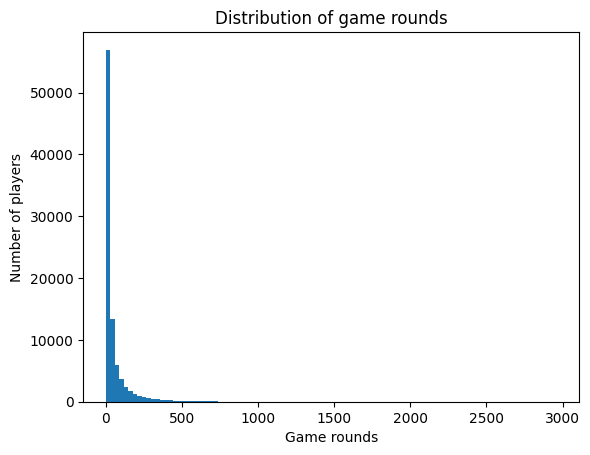

In [6]:
import matplotlib.pyplot as plt

plt.hist(df.loc[df['sum_gamerounds']<4000]['sum_gamerounds'], bins=100)
plt.xlabel('Game rounds')
plt.ylabel('Number of players')
plt.title('Distribution of game rounds')
plt.show()

In [7]:
# Remove the known extreme outlier
df_clean = df[df['sum_gamerounds'] < df['sum_gamerounds'].quantile(0.999)].copy()
print(f"Removed {len(df) - len(df_clean)} rows as outliers")

Removed 91 rows as outliers


In [8]:
group_30 = df_clean[df_clean['version'] == 'gate_30']
group_40 = df_clean[df_clean['version'] == 'gate_40']

**Null and Alternative Hypothesis**

For each retention metric, the null hypothesis is that the true retention rate is the same in both groups (p_gate30 = p_gate40), and the alternative hypothesis is that the rates differ (p_gate30 ≠ p_gate40). This is tested separately for 1-day retention and 7-day retention, since each captures a different stage of player engagement.

**The Practical Decision to influence**

We are trying to inform whether the gate should stay at level 30 or move to level 40.

In [9]:
#The retention rates and the sample sizes are really similar across control and treatment groups
baseline = df_clean.groupby('version')[['retention_1', 'retention_7']].mean()
group_sizes = df_clean['version'].value_counts()
 
print(baseline)
print(group_sizes)


         retention_1  retention_7
version                          
gate_30     0.447704     0.189458
gate_40     0.441713     0.181144
version
gate_40    45439
gate_30    44659
Name: count, dtype: int64


In [10]:
# Retrospective: what effect size could the actual sample size detect at 80% power?
n_per_group = group_sizes.min()
n_30 = len(group_30)
n_40 = len(group_40)
actual_ratio = n_40 / n_30

**Power Analysis**

In this section we are answering the following questions:

Given the sample size I actually have, a 5% significance threshold, and a desired 80% power, what is the smallest effect size I could reliably detect?

If I wanted to reliably detect a specific 1 percentage point lift, with the same significance level and power, how many players per group would I need?

In [11]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
 
power_analysis = NormalIndPower()
 

detectable_effect = power_analysis.solve_power(
    nobs1=n_30, alpha=0.05, power=0.8,
    ratio=actual_ratio #ratio of size of group1 relative to group2
)
print(f"Minimum detectable effect size: {detectable_effect:.4f}")
 
# Prospective: sample size needed to detect a 1 percentage point lift
# from a baseline retention rate of about 19% (retention_1)
target_effect = proportion_effectsize(0.20, 0.19)
required_n = power_analysis.solve_power(
    effect_size=target_effect, alpha=0.05, power=0.8, ratio=1.0
)
print(f"Required sample size per group: {required_n:.0f}")


Minimum detectable effect size: 0.0187
Required sample size per group: 24638


In [12]:
import numpy as np

def h_to_proportion(p1, h):
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = phi1 - h
    return np.sin(phi2 / 2) ** 2

baseline = baseline.loc['gate_30', 'retention_1']
p2 = h_to_proportion(baseline, detectable_effect)
print(f"With this sample size, we could detect a difference as small as {abs(p2 - baseline) * 100:.2f} percentage points")

With this sample size, we could detect a difference as small as 0.93 percentage points


**Brief Interpretation of Power Analysis**

If the true underlying difference in retention between the two groups is exactly 0.93 percentage points, in either direction, there is an 80% chance of the test correctly flagging that as statistically significant. If the true difference is smaller than that, the chance of detecting it drops below 80%, meaning the analysis is more likely to get a "not significant" result even though a real difference exists. If the observed difference in retention is larger than 0.93 points, the chance of detecting it is even higher than 80%.

**Hypothesis Testing**

This runs a two-proportion z-test, comparing the proportion of successes in group 1 against group 2, using counts and number of observations together to reconstruct each group's retention rate internally. It returns a z-statistic, which measures how many standard errors apart the two proportions are, and a p-value, the probability of seeing a difference this large or larger if there were actually no true difference between the groups.

In [13]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
 
for metric in ['retention_1', 'retention_7']:
    counts = np.array([group_30[metric].sum(), group_40[metric].sum()])
    nobs = np.array([len(group_30), len(group_40)])
    stat, pval = proportions_ztest(counts, nobs)
    print(f"{metric}: z = {stat:.3f}, p = {pval:.4f}")


retention_1: z = 1.809, p = 0.0704
retention_7: z = 3.212, p = 0.0013


In [14]:
# Minimum detectable effect for retention_1, converted to percentage points
baseline_p30 = group_30['retention_1'].mean()
p2_at_mde = h_to_proportion(baseline_p30, detectable_effect)
mde_pp = abs(p2_at_mde - baseline_p30) * 100

# Actual observed gap between groups
observed_p40 = group_40['retention_1'].mean()
observed_diff_pp = abs(baseline_p30 - observed_p40) * 100

print(f"Minimum detectable effect: {mde_pp:.2f} percentage points")
print(f"Observed difference in retention_1: {observed_diff_pp:.2f} percentage points")

if observed_diff_pp < mde_pp:
    print("The observed gap is smaller than what this sample size can reliably detect.")
    print("This may explain why retention_1 did not reach statistical significance,")
    print("even though a smaller real effect could still be present.")
else:
    print("The observed gap is at or above the minimum detectable effect,")
    print("so the lack of significance is less likely to be a power issue alone.")

Minimum detectable effect: 0.93 percentage points
Observed difference in retention_1: 0.60 percentage points
The observed gap is smaller than what this sample size can reliably detect.
This may explain why retention_1 did not reach statistical significance,
even though a smaller real effect could still be present.


**1-Day Retention Interpretation**

A p-value of 0.0704 is above the conventional 0.05 threshold, so this result is not statistically significant. There's about a 7% chance of seeing a gap this large between the groups purely by random sampling variation, even if moving the gate had no real effect on 1-day retention at all. We fail to reject the null hypothesis here, meaning there is not strong enough evidence to say gate placement affects 1-day retention. It's close to the threshold though, often described as a borderline or marginal result. However, as it will be examined later this result is due to the sample size not being able to capture the effect size for this group as the observed difference in retention is smaller than the detectable effect size.

**7-Day Retention Interpretation**

A p-value of 0.0013 is well below 0.05, so this result is statistically significant. There's only about a 0.13% chance of seeing a gap this large by random chance if there were truly no effect. We can reject the null hypothesis here and conclude there is a real difference in 7-day retention between the two groups.

Since counts and number of observations were built in the order gate_30 first and gate_40 after, a positive z-statistic means gate_30's retention rate is higher than gate_40's. So the practical conclusion is that moving the gate from level 30 to level 40 appears to slightly reduce 7-day retention, and the same direction shows up for 1-day retention, just not strongly enough to be statistically conclusive.

**Confidence Intervals**

retention_1 difference 95% CI: (-0.0005, 0.0125)
retention_7 difference 95% CI: (0.0032, 0.0134)


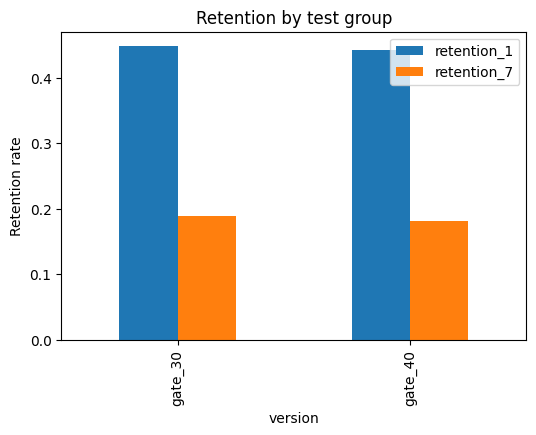

In [15]:
from statsmodels.stats.proportion import confint_proportions_2indep
import matplotlib.pyplot as plt
 
for metric in ['retention_1', 'retention_7']:
    ci_low, ci_upp = confint_proportions_2indep(
        group_30[metric].sum(), len(group_30),
        group_40[metric].sum(), len(group_40)
    )
    print(f"{metric} difference 95% CI: ({ci_low:.4f}, {ci_upp:.4f})")
 
retention_summary = df_clean.groupby('version')[['retention_1', 'retention_7']].mean()
retention_summary.plot(kind='bar', figsize=(6, 4))
plt.title('Retention by test group')
plt.ylabel('Retention rate')
plt.savefig('retention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**Confidence Intervals Interpretation**

**Retention_1: (-0.0005, 0.0125):**

This interval spans from about -0.05 percentage points to +1.25 percentage points. Since it crosses zero, it tells the true difference could plausibly be slightly negative, meaning gate_40 could actually be marginally better, even though the point estimate showed gate_30 ahead. This lines up exactly with the earlier p-value of 0.0704: a 95% confidence interval that includes zero is mathematically equivalent to a two-sided test that fails to reach significance at the 0.05 level. Both tell the same thing from two different angles, we can't confidently rule out that there's no real difference here.

**Retention_7: (0.0032, 0.0134)**

This interval spans from about 0.32 to 1.34 percentage points, entirely above zero. This is consistent with the p-value of 0.0013 being significant, since a CI that excludes zero corresponds to a significant two-sided test. We can say with 95% confidence that gate_30 genuinely outperforms gate_40 on 7-day retention, somewhere in that range.

This second interval is also useful for talking about practical significance, beyond just statistical significance. Even the upper bound is only 1.34 percentage points. So while the effect is real and statistically detectable, it's a fairly small effect in absolute terms. The data supports keeping the gate at level 30 rather than moving it, but the magnitude of that advantage is modest, not dramatic.

**Segment Analysis and Robustness checks**

I used Mann-Whitney U to test whether engagement, measured by game rounds played, differed between the two groups, since that's a different question from retention. I chose a rank-based test specifically because that variable is skewed with an outlier. Separately, I confirmed the outlier itself didn't meaningfully affect that result by rerunning it on the raw data.

In [16]:
from scipy.stats import mannwhitneyu
 
stat, pval = mannwhitneyu(group_30['sum_gamerounds'], group_40['sum_gamerounds'])
print(f"Mann-Whitney U test on game rounds: stat = {stat:.0f}, p = {pval:.4f}")
 
# Segment by engagement level
median_rounds = df_clean['sum_gamerounds'].median()
df_clean['engagement_segment'] = df_clean['sum_gamerounds'].apply(
    lambda x: 'high' if x > median_rounds else 'low'
)
segment_retention = df_clean.groupby(['engagement_segment', 'version'])['retention_7'].mean()
print(segment_retention)


Mann-Whitney U test on game rounds: stat = 1022467120, p = 0.0446
engagement_segment  version
high                gate_30    0.350912
                    gate_40    0.339824
low                 gate_30    0.025666
                    gate_40    0.025583
Name: retention_7, dtype: float64


In [17]:
print(group_30['sum_gamerounds'].median(), group_40['sum_gamerounds'].median())

17.0 16.0


The Mann-Whitney statistic changed by less than 0.2% with the outlier included, confirming the rank-based approach isn't meaningfully affected by it; the p-value crossing 0.05 in one direction or the other reflects how close to the threshold this particular comparison already was, not a real change in the underlying signal.

In [18]:
group_30_raw = df[df['version'] == 'gate_30']
group_40_raw = df[df['version'] == 'gate_40']

stat_raw, pval_raw = mannwhitneyu(group_30_raw['sum_gamerounds'], group_40_raw['sum_gamerounds'])
print(f"Mann-Whitney on raw data: stat = {stat_raw:.0f}, p = {pval_raw:.4f}")
print(f"Mann-Whitney on cleaned data: stat = {stat:.0f}, p = {pval:.4f}")

Mann-Whitney on raw data: stat = 1024331250, p = 0.0502
Mann-Whitney on cleaned data: stat = 1022467120, p = 0.0446


The engagement split shows something genuinely useful. Among high-engagement players, those above the median in game rounds played, gate_30 has a 7-day retention of 35.09% compared to 33.98% for gate_40, a gap of roughly 1.1 percentage points in the same direction as the overall finding. Among low-engagement players, the gap nearly disappears: 2.567% versus 2.558%, a difference of less than a hundredth of a point.

This is a strong robustness result for two reasons. First, it confirms my original conclusion isn't an artifact, since the effect shows up consistently in the segment where it should matter most. Second, it adds a layer of business insight that my original analysis didn't have: the effect of gate placement is concentrated almost entirely among engaged players. That actually makes intuitive sense, since low-engagement players who play very few rounds likely never reach level 30 or 40 in the first place, so where the gate sits couldn't possibly affect their experience. The fact that the data lines up with that logical expectation is a good face-validity check, it's the kind of thing that makes my finding trustworthy rather than coincidental.

**Interpreting the Mann-Whitney result**

The Mann-Whitney test is a hypothesis test that compares two independent groups using ranks rather than raw values. This method is robust to skewed distributions and outliers because it doesn't use the raw values, it counts how many times a value from one group is ranked higher than the same value for another group across all possible pairings between the two groups. Under ranking, that same player with 49,854 rounds simply becomes the single highest rank in the dataset, whether their actual value was 50,000 or 5,000 makes no difference to the calculation, since rank position only reflects order, not magnitude.

The p-value of 0.0446 is just under the 0.05 threshold, so the overall distribution of game rounds played does differ significantly between gate_30 and gate_40, where gate_30 has higher median game rounds though it's a fairly borderline result, not a strong signal.

**Conclusion**

The analysis provides clear evidence that moving the gate from level 30 to level 40 has a negative effect on 7-day player retention. Gate_30 outperforms gate_40 by approximately 0.83 percentage points on 7-day retention, a difference that is statistically significant at the 0.05 level (z = 3.212, p = 0.0013) with a 95% confidence interval of 0.32 to 1.34 percentage points entirely above zero. For 1-day retention the result is not statistically significant (p = 0.0704), however the observed difference of 0.61 percentage points falls below the minimum detectable effect of 0.93 percentage points for this sample size, suggesting a real but smaller effect may exist that this test lacks sufficient power to confirm. The segment analysis reinforces these findings: the retention advantage of gate_30 is concentrated almost entirely among high-engagement players, those above the median in game rounds played, which aligns with the intuition that low-engagement players likely never reach either gate in the first place. The Mann-Whitney test further confirms that gate_30 players show marginally higher overall engagement, with the difference in game rounds played approaching but not firmly crossing the significance threshold (p = 0.0446). Taken together, the evidence supports keeping the gate at level 30 rather than moving it to level 40, with the caveat that the absolute magnitude of the retention difference is modest, roughly one percentage point, meaning the business impact should be weighed against any other product or monetization considerations that may favor the level 40 placement.